# ROUND 3

Min W     = -1.8768812417984009, Max W     = 1.3587578535079956
Min XcWWT = -8.45975112915039, Max XcWWT = 7.755061626434326
Min Xc    = -2.3109750747680664, Max Xc    = 2.2721590995788574


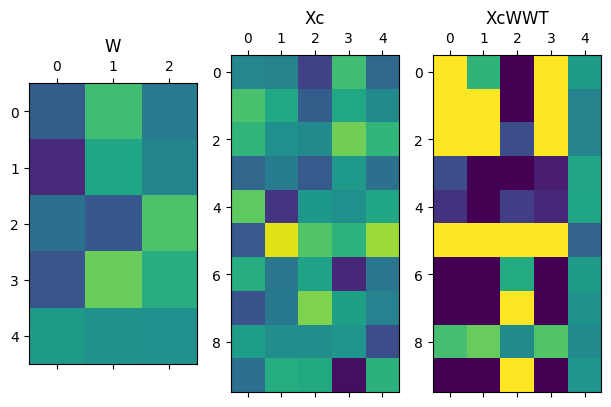

   0 - loss= 10.979561, lr=0.0100000000
 100 - loss=  0.631515, lr=0.0097552826
 200 - loss=  0.298161, lr=0.0090450850
 300 - loss=  0.253630, lr=0.0079389263
 400 - loss=  0.222737, lr=0.0065450850
 500 - loss=  0.185228, lr=0.0050000000
 600 - loss=  0.172385, lr=0.0034549150
 700 - loss=  0.167461, lr=0.0020610737
 800 - loss=  0.165422, lr=0.0009549150
 900 - loss=  0.164714, lr=0.0002447174
Min W     = -0.7030910849571228, Max W     = 0.8370270729064941
Min XcWWT = -1.897383451461792, Max XcWWT = 2.5182695388793945
Min Xc    = -2.3109750747680664, Max Xc    = 2.2721590995788574


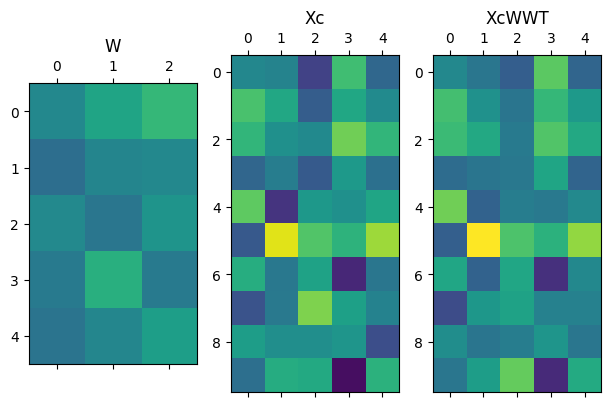

 999 - loss=  0.164609, lr=0.0000000247


In [1]:
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt


N = 10
n = 5
k = 3

X = torch.randn(N, n)
Xc = X - X.mean(0, keepdim=True)
W = torch.randn(n, k, requires_grad=True)

steps = 1000
opt = torch.optim.AdamW([W], lr=1e-2)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=steps)

for step in range(steps):
  XcW = Xc @ W
  XcWWT = XcW @ W.T

  if step == 0 or step == steps-1:
    print(f'Min W     = {W.min()    }, Max W     = {W.max()}')
    print(f'Min XcWWT = {XcWWT.min()}, Max XcWWT = {XcWWT.max()}')
    print(f'Min Xc    = {Xc.min()   }, Max Xc    = {Xc.max()}')
    plt.figure(figsize=(10,5))
    plt.subplot(1,4,1)
    plt.matshow(W.detach(), fignum=False, vmin=-2.5, vmax=2.5)
    plt.title("W")
    plt.subplot(1,4,2)
    plt.matshow(Xc, fignum=False, vmin=-2.5, vmax=2.5)
    plt.title("Xc")
    plt.subplot(1,4,3)
    plt.matshow(XcWWT.detach(), fignum=False, vmin=-2.5, vmax=2.5)
    plt.title("XcWWT")
    plt.show()

  loss = torch.nn.functional.mse_loss(XcWWT, Xc)

  if step % (steps // 10) == 0 or step == steps - 1: print(f'{step:4} - loss={loss.item():10f}, lr={sch.get_last_lr()[0]:.10f}' )

  opt.zero_grad()
  loss.backward()
  opt.step()
  sch.step()

# Questions:
1. Wat is hierdie W matrix? Want met n gewone NN sal ek n encoder en decoder layer gebruik het. Maar hierdie W dien as altwee.